<center><image src="https://drive.google.com/uc?id=1n3G4TdK_u6PQHcLrxB_A0HijNdigXmUH">

<h1 style="text-align: center;"><b>Game of Thrones Character Survival Prediction</b></h1>


Проект по классификации выживаемости персонажей на табличных данных из A Wiki of Ice and Fire.


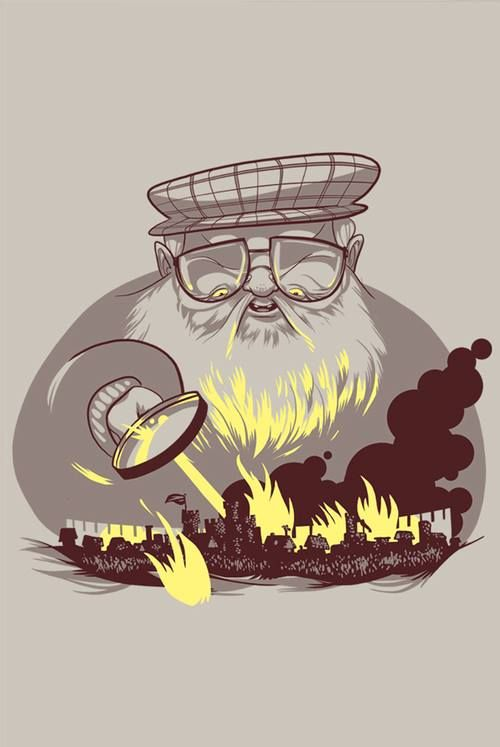

В проекте используется датасет по персонажам вселенной Game of Thrones. Цель - предсказать, выживет персонаж или нет.


Описание данных:

* **name**: Имя персонажа

* **Title**: Социальный статус или знатность

* **House**: Дом, к которому принадлежит персонаж

* **Culture**: Социальная группа, к которой принадлежит персонаж

* **book1/2/3/4/5**: Появление персонажа в книге

* **Is noble**: Знатность персонажа, основанное на титуле

* **Age**: Отсчет времени: 305 AC

* **male**: Мужчина или женщина

* **dateOfBirth**: дата рождения

* **Spouse**: Имя супруги\а персонажа

* **Father**: Имя отца персонажа

* **Mother**: Имя матери персонажа

* **Heir**: Имя наследника персонажа

* **Is married**: Represents whether the character is married

* **Is spouse alive**: Represents whether character's spouse is alive

* **Is mother alive:** Жива ли мать персонажа

* **Is heir alive:** Жив ли наследник персонажа

* **Is father alive:** Указывает, жив ли отец персонажа

* **Number dead relations:** Количество умерших персонажей, с которыми персонаж связан

* **Popularity score:** Количество внутренних входящих и исходящих ссылок на страницу персонажей в вики http://awoiaf.westeros.org

Целевая переменная:
* **isAlive**: жив ли персонаж в книге

## Анализ и предобработка данных


В этом разделе выполняются очистка данных, создание признаков и подготовка выборки для обучения моделей.


Загрузка датасета


In [ ]:
!gdown 1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3 # test dataset
!gdown 1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v # train dataset

Downloading...
From: https://drive.google.com/uc?id=1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3
To: /content/game_of_thrones_test.csv
100% 37.3k/37.3k [00:00<00:00, 44.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v
To: /content/game_of_thrones_train.csv
100% 138k/138k [00:00<00:00, 52.1MB/s]


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.impute import KNNImputer

In [ ]:
df = pd.read_csv("/content/game_of_thrones_train.csv", index_col="S.No")

### Очистка данных

Анализирую пропуски и выбираю стратегию заполнения или удаления в зависимости от признака.


In [ ]:
df.isna().sum(axis=0)

,0
name,0
title,840
male,0
culture,1069
dateOfBirth,1278
mother,1539
father,1535
heir,1536
house,381
spouse,1357


Удаляю признаки, которые не дают полезного сигнала модели или дублируют уже извлеченную информацию.


In [ ]:
df.drop(columns=['mother', 'father', 'heir', 'spouse', 'isAliveMother', 'isAliveFather', 'isAliveHeir', 'isAliveSpouse'], inplace=True)

In [ ]:
df['age'].unique()

array([ nan,  97.,  23.,  29.,  26.,  16.,  25.,  59.,  19.,  27.,  22.,
       100.,  14.,  42.,  35.,   3.,  55.,  15.,  21.,  53.,   6.,  37.,
        11.,  17.,  10.,  20.,  45.,   9.,  24.,  13.,  52.,  50.,   2.,
        56.,   0.,  39.,  12.,  85.,  54.,  28.,  31.,  61.,  18.,  70.,
        94.,  65.,  64.,  79.,  40.,  49.,  76.,  41.,   7.,   8.,  46.,
        30.,  51.,  75.,  82.,  43.,  81.,  60.,  47.,  69.,  36.,  68.,
        48.,  38.,  33.,  86.,  80.,  58.,  77.])

<BarContainer object of 17 artists>

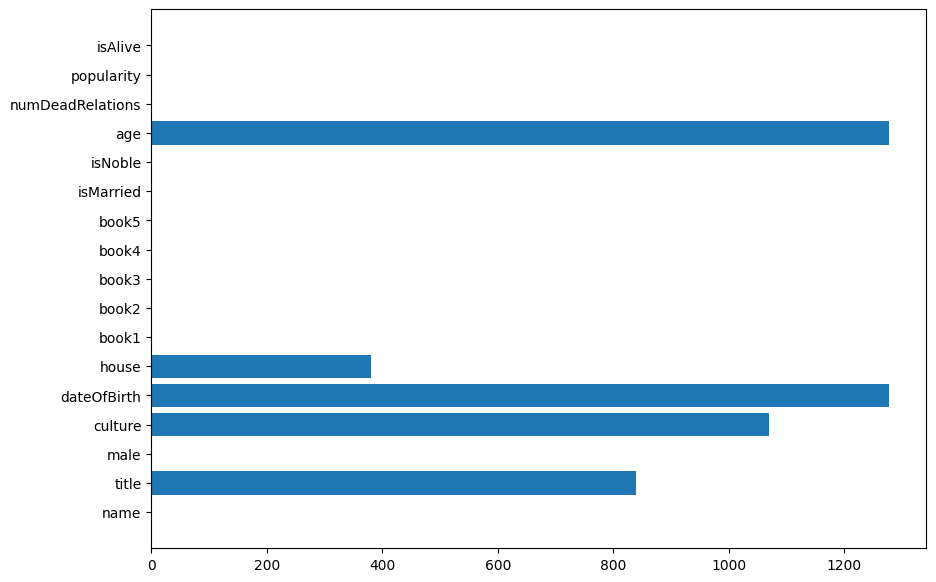

In [ ]:
data = df.isna().sum()

plt.figure(figsize=(10,7))

plt.barh(data.index, data.values)

<Axes: xlabel='S.No'>

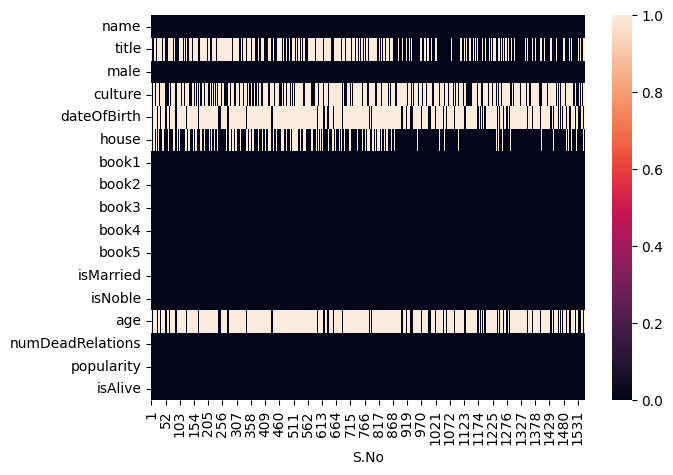

In [ ]:
plt.figure(figsize=(7,5))
sns.heatmap(df.isna().transpose())

Пропуски в возрасте заполняю модой как простым базовым приближением.


In [ ]:
mod = df["age"].mode()[0]
df["age"].fillna(mod, inplace=True)

<ipython-input-9-47fbb9adc08d>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["age"].fillna(mod, inplace=True)


In [ ]:
df.isna().sum()

,0
name,0
title,840
male,0
culture,1069
dateOfBirth,1278
house,381
book1,0
book2,0
book3,0
book4,0


In [ ]:
len(df)

1557

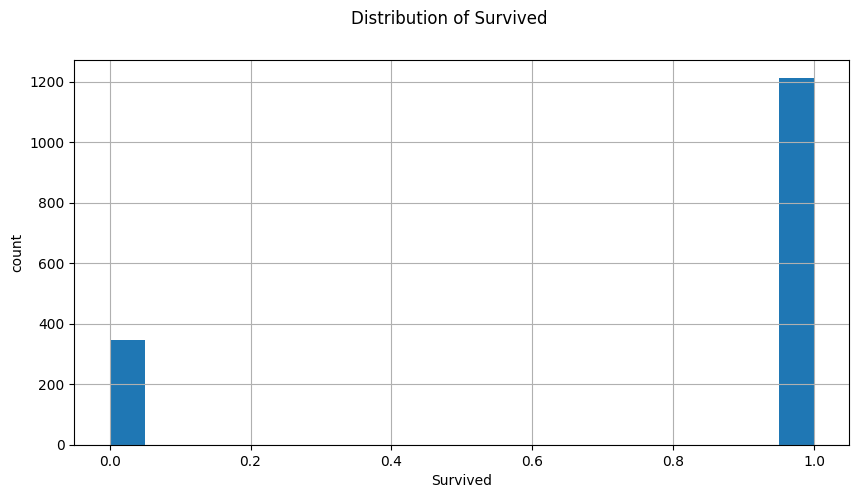

In [ ]:
plt.figure(figsize = (10, 5))

df['isAlive'].hist(density=False, bins=20)
plt.ylabel('count')
plt.xlabel('Survived')

plt.suptitle('Distribution of Survived')
plt.show()

Для уменьшения пропусков в `House` пробую восстановить часть значений по связанным текстовым полям.


In [ ]:

houses = df['house'].unique()
nan_house_df = df[df['house'].isna()]
nan_house_df['last_name'] = nan_house_df['name'].str.split().str[-1]
nan_house_df['potential_house'] = "House " + nan_house_df['last_name']
nan_house_df['valid_house'] = nan_house_df['potential_house'].apply(lambda x: x if x in houses else np.nan)
df.loc[df['house'].isna(), 'house'] = nan_house_df['valid_house']



<ipython-input-14-02c50596ef83>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nan_house_df['last_name'] = nan_house_df['name'].str.split().str[-1]
<ipython-input-14-02c50596ef83>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nan_house_df['potential_house'] = "House " + nan_house_df['last_name']
<ipython-input-14-02c50596ef83>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the doc

In [ ]:
df.isna().sum()

,0
name,0
title,840
male,0
culture,1069
dateOfBirth,1278
house,343
book1,0
book2,0
book3,0
book4,0


После первичной очистки качество и полнота признаков стали лучше.


После извлечения полезной информации из имени удаляю исходный текстовый столбец.


In [ ]:
df.drop(columns=['name'])

,title,male,culture,dateOfBirth,house,book1,book2,book3,book4,book5,isMarried,isNoble,age,numDeadRelations,popularity,isAlive
S.No,,,,,,,,,,,,,,,,
1,NaN,1,NaN,NaN,House Targaryen,0,0,0,0,0,0,0,100.0,11,0.605351,0
2,Lord of the Crossing,1,Rivermen,208.0,House Frey,1,1,1,1,1,1,1,97.0,1,0.896321,1
3,Ser,1,NaN,NaN,House Swyft,0,0,0,1,0,0,1,100.0,0,0.267559,1
4,Queen,0,NaN,82.0,House Arryn,0,0,0,0,0,1,1,23.0,0,0.183946,0
5,Greenstone,0,Dornish,276.0,House Santagar,0,0,0,1,0,1,1,29.0,0,0.043478,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1553,Archmaester,1,NaN,NaN,NaN,1,0,1,1,0,0,1,100.0,0,0.160535,1
1554,NaN,0,NaN,NaN,House Heddle,1,1,0,0,0,0,0,100.0,0,0.040134,0
1555,NaN,1,NaN,NaN,House Seaworth,0,1,1,1,1,0,0,100.0,0,0.076923,0


### Feature engineering

Добавляю бинарные и агрегированные признаки, связанные с популярностью персонажа, окружением и культурной группой.


In [ ]:
df['isPopular'] = df['popularity'].apply(lambda x: 1 if x > 0.5 else 0)
df.drop(columns=['popularity'])

,name,title,male,culture,dateOfBirth,house,book1,book2,book3,book4,book5,isMarried,isNoble,age,numDeadRelations,isAlive,isPopular
S.No,,,,,,,,,,,,,,,,,
1,Viserys II Targaryen,NaN,1,NaN,NaN,House Targaryen,0,0,0,0,0,0,0,100.0,11,0,1
2,Walder Frey,Lord of the Crossing,1,Rivermen,208.0,House Frey,1,1,1,1,1,1,1,97.0,1,1,1
3,Addison Hill,Ser,1,NaN,NaN,House Swyft,0,0,0,1,0,0,1,100.0,0,1,0
4,Aemma Arryn,Queen,0,NaN,82.0,House Arryn,0,0,0,0,0,1,1,23.0,0,0,0
5,Sylva Santagar,Greenstone,0,Dornish,276.0,House Santagar,0,0,0,1,0,1,1,29.0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1553,Marwyn,Archmaester,1,NaN,NaN,NaN,1,0,1,1,0,0,1,100.0,0,1,0
1554,Masha Heddle,NaN,0,NaN,NaN,House Heddle,1,1,0,0,0,0,0,100.0,0,0,0
1555,Matthos Seaworth,NaN,1,NaN,NaN,House Seaworth,0,1,1,1,1,0,0,100.0,0,0,0


In [ ]:
df['boolDeadRelations'] = df['numDeadRelations'].apply(lambda x: 0 if x == 0 else 1)
df.drop(columns=['numDeadRelations'])

,name,title,male,culture,dateOfBirth,house,book1,book2,book3,book4,book5,isMarried,isNoble,age,popularity,isAlive,isPopular,boolDeadRelations
S.No,,,,,,,,,,,,,,,,,,
1,Viserys II Targaryen,NaN,1,NaN,NaN,House Targaryen,0,0,0,0,0,0,0,100.0,0.605351,0,1,1
2,Walder Frey,Lord of the Crossing,1,Rivermen,208.0,House Frey,1,1,1,1,1,1,1,97.0,0.896321,1,1,1
3,Addison Hill,Ser,1,NaN,NaN,House Swyft,0,0,0,1,0,0,1,100.0,0.267559,1,0,0
4,Aemma Arryn,Queen,0,NaN,82.0,House Arryn,0,0,0,0,0,1,1,23.0,0.183946,0,0,0
5,Sylva Santagar,Greenstone,0,Dornish,276.0,House Santagar,0,0,0,1,0,1,1,29.0,0.043478,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1553,Marwyn,Archmaester,1,NaN,NaN,NaN,1,0,1,1,0,0,1,100.0,0.160535,1,0,0
1554,Masha Heddle,NaN,0,NaN,NaN,House Heddle,1,1,0,0,0,0,0,100.0,0.040134,0,0,0
1555,Matthos Seaworth,NaN,1,NaN,NaN,House Seaworth,0,1,1,1,1,0,0,100.0,0.076923,0,0,0


In [ ]:
len(df['culture'].unique())

52

In [ ]:
# Подсказка
cult = {
    'Summer Islands': ['summer islands', 'summer islander', 'summer isles'],
    'Ghiscari': ['ghiscari', 'ghiscaricari',  'ghis'],
    'Asshai': ["asshai'i", 'asshai'],
    'Lysene': ['lysene', 'lyseni'],
    'Andal': ['andal', 'andals'],
    'Braavosi': ['braavosi', 'braavos'],
    'Dornish': ['dornishmen', 'dorne', 'dornish'],
    'Myrish': ['myr', 'myrish', 'myrmen'],
    'Westermen': ['westermen', 'westerman', 'westerlands'],
    'Westerosi': ['westeros', 'westerosi'],
    'Stormlander': ['stormlands', 'stormlander'],
    'Norvoshi': ['norvos', 'norvoshi'],
    'Northmen': ['the north', 'northmen'],
    'Free Folk': ['wildling', 'first men', 'free folk'],
    'Qartheen': ['qartheen', 'qarth'],
    'Reach': ['the reach', 'reach', 'reachmen'],
}

def replace_culture(culture_value):
  for key, values in cult.items():
    if str(culture_value).lower() in values:
      return key
  return culture_value


df['culture'] = df['culture'].apply(replace_culture)


In [ ]:
len(df['culture'].unique())

35

In [ ]:
df.drop(columns=['culture'], inplace = True)

In [ ]:
df.drop(columns=['popularity'], inplace = True)

In [ ]:
df.drop(columns=['numDeadRelations'], inplace = True)

In [ ]:
df.isna().sum()

,0
name,0
title,840
male,0
dateOfBirth,1278
house,343
book1,0
book2,0
book3,0
book4,0
book5,0


In [ ]:
data = df['isAlive'].value_counts()

data

,count
isAlive,
1,1212
0,345


In [ ]:
df['title'].value_counts()
df['title'] = df['title'].fillna('No title')

In [ ]:
title_counts = df['title'].value_counts()

In [ ]:
df['title'] = df['title'].apply(lambda x: 'rare' if title_counts[x] < 29 else 'common')


In [ ]:
df['title'].value_counts()

,count
title,
common,1175
rare,382


In [ ]:
df['house'].isna().sum()

343

In [ ]:
df['house'].value_counts()

,count
house,
House Frey,91
Night's Watch,88
House Stark,60
House Targaryen,54
House Lannister,37
...,...
House Celtigar,1
House of Ghazeen,1
House Byrch,1


Пробую дополнительное заполнение пропусков в `House` модой как базовый вариант.


In [ ]:
moda = df['house'].mode()[0]

In [ ]:
df['house'].fillna(moda, inplace=True)

<ipython-input-35-0b6fe9f177a2>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['house'].fillna(moda, inplace=True)


In [ ]:
df.isna().sum()

,0
name,0
title,0
male,0
dateOfBirth,1278
house,0
book1,0
book2,0
book3,0
book4,0
book5,0


In [ ]:
mod = df['dateOfBirth'].mode()[0]
df.fillna({'dateOfBirth': mod}, inplace=True)

In [ ]:
df['def_dead'] = np.where((df['age'] + df['dateOfBirth']) < 305, 1, 0)


Из-за высокой корреляции между `dateOfBirth` и `Age` удаляю менее удобный для модели признак.


In [ ]:
df.drop(columns='dateOfBirth', inplace=True)

In [ ]:
from sklearn.cluster import KMeans
house_counts = df['house'].value_counts()

house_counts_reshaped = np.array(house_counts).reshape(-1, 1)

kmeans = KMeans(n_clusters=3, random_state=0).fit(house_counts_reshaped)

house_cluster_mapping = dict(zip(house_counts.index, kmeans.labels_))

df['house'] = df['house'].map(house_cluster_mapping)

df

,name,title,male,house,book1,book2,book3,book4,book5,isMarried,isNoble,age,isAlive,isPopular,boolDeadRelations,def_dead
S.No,,,,,,,,,,,,,,,,
1,Viserys II Targaryen,common,1,2,0,0,0,0,0,0,0,100.0,0,1,1,0
2,Walder Frey,rare,1,1,1,1,1,1,1,1,1,97.0,1,1,1,0
3,Addison Hill,common,1,0,0,0,0,1,0,0,1,100.0,1,0,0,0
4,Aemma Arryn,rare,0,0,0,0,0,0,0,1,1,23.0,0,0,0,1
5,Sylva Santagar,rare,0,0,0,0,0,1,0,1,1,29.0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1553,Marwyn,rare,1,1,1,0,1,1,0,0,1,100.0,1,0,0,0
1554,Masha Heddle,common,0,0,1,1,0,0,0,0,0,100.0,0,0,0,0
1555,Matthos Seaworth,common,1,0,0,1,1,1,1,0,0,100.0,0,0,0,0


In [ ]:
df['isTitleCommon'] = df['title'].apply(lambda x: 1 if x == 'common' else 0)

In [ ]:
df.drop(columns=['name', 'title'], inplace=True)

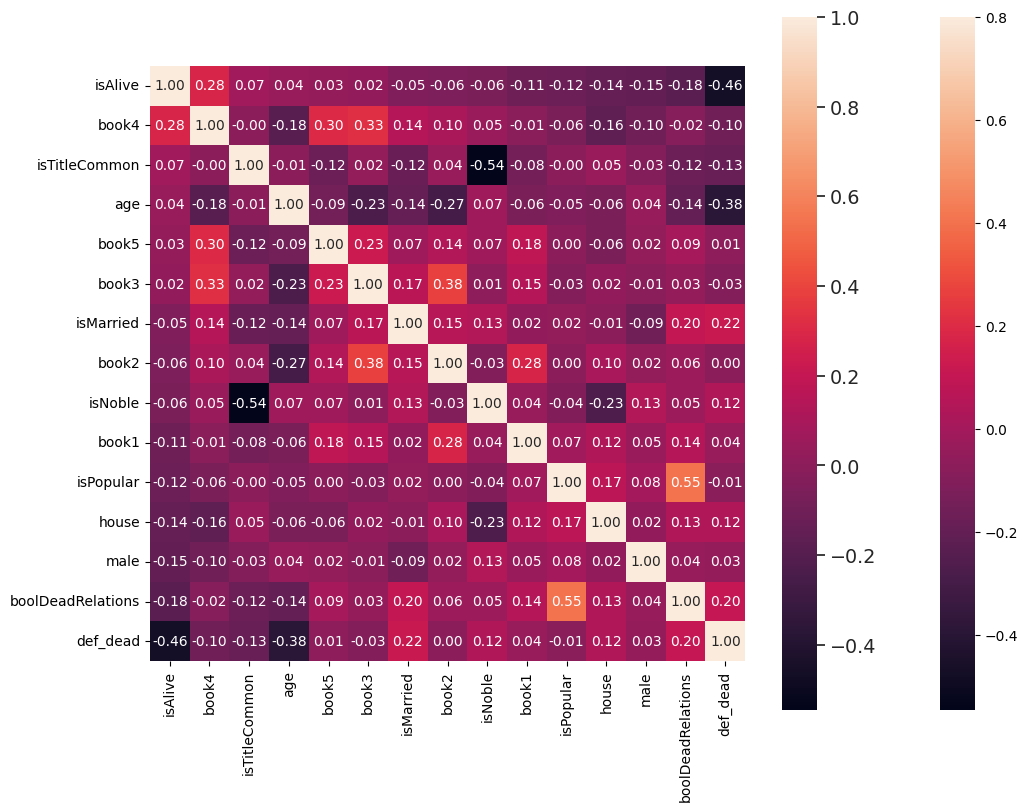

In [ ]:
corrmat = df.corr()
f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corrmat, vmax=.8, square=True);
# correlation matrix
k = 16 # number of variables for heatmap
cols = corrmat.nlargest(k, 'isAlive')['isAlive'].index
cm = np.corrcoef(df[cols].values.T)
sns.set(font_scale=1.25)
hm = sns.heatmap(cm, cbar=True, annot=True, square=True, fmt='.2f', annot_kws={'size': 10}, yticklabels=cols.values, xticklabels=cols.values)
plt.show()

In [ ]:
df.drop(columns=['dateOfBirth', 'isNoble'], inplace=True)

KeyError: "['dateOfBirth'] not found in axis"

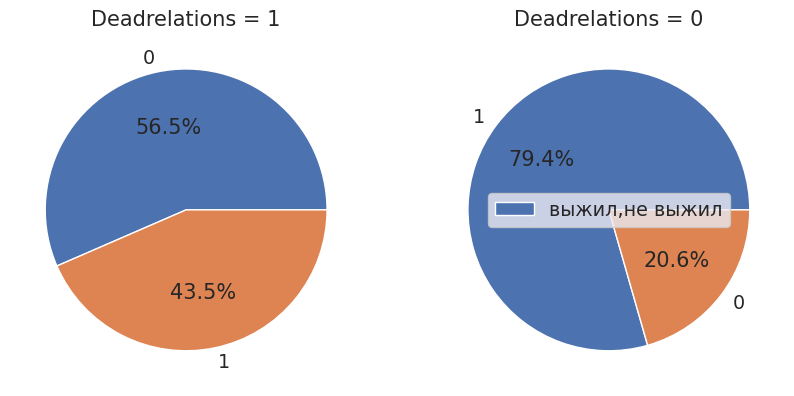

In [ ]:
data1 = df[df['boolDeadRelations'] == 1]['isAlive'].value_counts()
data2 = df[df['boolDeadRelations'] == 0]['isAlive'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,8))

ax1.pie(data1.values, labels=data1.index, autopct='%1.1f%%')
ax2.pie(data2.values, labels=data2.index, autopct='%1.1f%%')

ax1.set_title("Deadrelations = 1")
ax2.set_title("Deadrelations = 0")

plt.legend(['выжил,не выжил'])

plt.show()

In [ ]:
X = df.drop(columns=['isAlive']).values
y = df['isAlive'].values

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)
# Выход pca - numpy матрица, положим ее в новую переменную со всеми фичами
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(X_train)
# Выход pca - numpy матрица, положим ее в новую переменную со всеми фичами
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Обучение моделей


На этом этапе сравниваю несколько алгоритмов классификации из `sklearn`.


In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

In [ ]:
param_grid = {
    'max_depth': np.arange(1, 5), # также можно указать обычный массив, [1, 2, 3, 4]
    'min_samples_leaf': [1,2, 3],
}

In [ ]:
# Шаг 1. создание модели
logistic_regression = LogisticRegression(C=1)

# Шаг 2. обучение модели
logistic_regression.fit(X_train, y_train)

# Шаг 3. Предсказание на тестовых данных
y_pred = logistic_regression.predict(X_test)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
base_estimator = DecisionTreeClassifier(max_depth=1)
ada_model = AdaBoostClassifier(estimator=base_estimator, n_estimators=50, random_state=42)

ada_model.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                   random_state=42)

In [ ]:
from sklearn.metrics import make_scorer, accuracy_score

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)


param_grid = {
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10]
}


gridsearch_rf = GridSearchCV(rf_model, param_grid, refit=True, scoring=make_scorer(accuracy_score))


gridsearch_rf.fit(X_train, y_train)

print(gridsearch_rf.best_params_)

rf_pred = gridsearch_rf.predict(X_test)

{'max_depth': 10, 'min_samples_split': 5}


## Оценка качества


Для сравнения моделей использую метрику `accuracy` на отложенной выборке.


In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:

y_pred = logistic_regression.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
print("Accuracy : %.4f" % accuracy)

Accuracy : 0.8462


In [ ]:
ada_pred = ada_model.predict(X_test)

ada_accuracy = accuracy_score(y_test, ada_pred)
print("Accuracy : %.4f" % ada_accuracy)

Accuracy : 0.8494


In [ ]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Accuracy : %.4f" % rf_accuracy)

Accuracy : 0.8462


Сравнение результатов моделей


Лучшей по `accuracy` оказалась модель `AdaBoost`.


## Экспорт предсказаний


Тестовая выборка приводится к той же структуре признаков, что и обучающая, после чего формируется `submission.csv`.


In [ ]:
df_test = pd.read_csv("/content/game_of_thrones_test.csv", index_col="S.No")


,name,title,male,culture,dateOfBirth,mother,father,heir,house,spouse,...,book5,isAliveMother,isAliveFather,isAliveHeir,isAliveSpouse,isMarried,isNoble,age,numDeadRelations,popularity
S.No,,,,,,,,,,,,,,,,,,,,,
1558,Melissa Blackwood,NaN,0,NaN,156.0,NaN,NaN,NaN,House Blackwood,NaN,...,1,NaN,NaN,NaN,NaN,0,0,100.0,0,0.050167
1559,Melisandre,NaN,0,Asshai,NaN,NaN,NaN,NaN,R'hllor,NaN,...,1,NaN,NaN,NaN,NaN,0,0,NaN,0,0.745819
1560,Merrit,NaN,0,NaN,NaN,NaN,NaN,NaN,Brotherhood without banners,NaN,...,0,NaN,NaN,NaN,NaN,0,0,NaN,0,0.010033
1561,Meryn Trant,Ser,1,NaN,NaN,NaN,NaN,NaN,House Trant,NaN,...,1,NaN,NaN,NaN,NaN,0,1,NaN,0,0.220736
1562,Merrett Frey,NaN,1,Riverlands,262.0,NaN,NaN,NaN,House Frey,Mariya Darry,...,1,NaN,NaN,NaN,1.0,1,0,38.0,0,0.434783
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1942,Luwin,NaN,1,Westeros,NaN,NaN,NaN,NaN,House Stark,NaN,...,1,NaN,NaN,NaN,NaN,0,0,NaN,0,0.351171
1943,Reek,NaN,1,NaN,NaN,NaN,NaN,NaN,House Bolton,NaN,...,1,NaN,NaN,NaN,NaN,0,0,NaN,0,0.096990
1944,Symeon Star-Eyes,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1,NaN,NaN,NaN,NaN,0,0,NaN,0,0.030100


In [ ]:
df_test['isAlive'] = 0

In [ ]:
df_test.drop(columns=['isAliveMother', 'isAliveFather', 'isAliveHeir', 'isAliveSpouse'], inplace=True)
mod_test = df_test["age"].mode()[0]
df_test["age"].fillna(mod_test, inplace=True)

<ipython-input-65-9ce42130710a>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_test["age"].fillna(mod_test, inplace=True)


In [ ]:
cult = {
    'Summer Islands': ['summer islands', 'summer islander', 'summer isles'],
    'Ghiscari': ['ghiscari', 'ghiscaricari',  'ghis'],
    'Asshai': ["asshai'i", 'asshai'],
    'Lysene': ['lysene', 'lyseni'],
    'Andal': ['andal', 'andals'],
    'Braavosi': ['braavosi', 'braavos'],
    'Dornish': ['dornishmen', 'dorne', 'dornish'],
    'Myrish': ['myr', 'myrish', 'myrmen'],
    'Westermen': ['westermen', 'westerman', 'westerlands'],
    'Westerosi': ['westeros', 'westerosi'],
    'Stormlander': ['stormlands', 'stormlander'],
    'Norvoshi': ['norvos', 'norvoshi'],
    'Northmen': ['the north', 'northmen'],
    'Free Folk': ['wildling', 'first men', 'free folk'],
    'Qartheen': ['qartheen', 'qarth'],
    'Reach': ['the reach', 'reach', 'reachmen'],
}

def replace_culture(culture_value):
  for key, values in cult.items():
    if str(culture_value).lower() in values:
      return key
  return culture_value


df_test['culture'] = df_test['culture'].apply(replace_culture)

In [ ]:
houses_test = df_test['house'].unique()
nan_house_df_test = df_test[df_test['house'].isna()]
nan_house_df_test['last_name'] = nan_house_df_test['name'].str.split().str[-1]
nan_house_df_test['potential_house'] = "House " + nan_house_df_test['last_name']
nan_house_df_test['valid_house'] = nan_house_df_test['potential_house'].apply(lambda x: x if x in houses_test else np.nan)
df.loc[df['house'].isna(), 'house'] = nan_house_df['valid_house']


<ipython-input-69-299a242c33ff>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nan_house_df_test['last_name'] = nan_house_df_test['name'].str.split().str[-1]
<ipython-input-69-299a242c33ff>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nan_house_df_test['potential_house'] = "House " + nan_house_df_test['last_name']
<ipython-input-69-299a242c33ff>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See th

In [ ]:
df_test.drop(columns=['name'], inplace=True)

df_test['isPopular'] = df_test['popularity'].apply(lambda x: 1 if x > 0.5 else 0)
df_test.drop(columns=['popularity'], inplace=True)

df_test['boolDeadRelations'] = df_test['numDeadRelations'].apply(lambda x: 0 if x == 0 else 1)
df_test.drop(columns=['numDeadRelations'], inplace=True)


In [ ]:
df_test['title'].value_counts()
df_test['title'] = df_test['title'].fillna('No title')
title_counts_test = df_test['title'].value_counts()
df_test['title'] = df_test['title'].apply(lambda x: 'rare' if title_counts_test[x] < 29 else 'common')

In [ ]:
moda_test = df_test['house'].mode()[0]
df_test['house'].fillna(moda_test, inplace=True)

<ipython-input-73-baa79a049d03>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_test['house'].fillna(moda_test, inplace=True)


In [ ]:
mod_test = df_test['dateOfBirth'].mode()[0]
df_test.fillna({'dateOfBirth': mod_test}, inplace=True)

In [ ]:
df_test['def_dead'] = np.where((df_test['age'] + df_test['dateOfBirth']) < 305, 1, 0)

df_test.drop(columns='dateOfBirth', inplace=True)

In [ ]:
from sklearn.cluster import KMeans
house_counts_test = df_test['house'].value_counts()

house_counts_reshaped_test = np.array(house_counts_test).reshape(-1, 1)

kmeans_test = KMeans(n_clusters=3, random_state=0).fit(house_counts_reshaped_test)

house_cluster_mapping_test = dict(zip(house_counts_test.index, kmeans.labels_))

df_test['house'] = df_test['house'].map(house_cluster_mapping_test)

df_test['isTitleCommon'] = df_test['title'].apply(lambda x: 1 if x == 'common' else 0)
df_test.drop(columns='isNoble', inplace=True)

In [ ]:
df_test.drop(columns=['mother', 'father', 'heir', 'spouse'], inplace=True)

,title,male,culture,house,book1,book2,book3,book4,book5,isMarried,age,isAlive,isPopular,boolDeadRelations,def_dead,isTitleCommon
S.No,,,,,,,,,,,,,,,,
1558,common,0,NaN,0,0,0,0,0,1,0,100.0,0,0,0,1,1
1559,common,0,Asshai,0,0,1,1,1,1,0,100.0,0,1,0,0,1
1560,common,0,NaN,0,0,0,1,1,0,0,100.0,0,0,0,0,1
1561,common,1,NaN,0,1,1,1,1,1,0,100.0,0,0,0,0,1
1562,common,1,Riverlands,0,1,1,1,1,1,1,38.0,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1942,common,1,Westerosi,2,1,1,1,1,1,0,100.0,0,0,0,0,1
1943,common,1,NaN,0,0,1,0,1,1,0,100.0,0,0,0,0,1
1944,common,1,NaN,1,1,1,1,1,1,0,100.0,0,0,0,0,1


In [ ]:
df_test.drop(columns=['culture'], inplace = True)

In [ ]:
df_test.drop(columns=['title'], inplace = True)


,male,house,book1,book2,book3,book4,book5,isMarried,age,isAlive,isPopular,boolDeadRelations,def_dead,isTitleCommon
S.No,,,,,,,,,,,,,,
1558,0,0,0,0,0,0,1,0,100.0,0,0,0,1,1
1559,0,0,0,1,1,1,1,0,100.0,0,1,0,0,1
1560,0,0,0,0,1,1,0,0,100.0,0,0,0,0,1
1561,1,0,1,1,1,1,1,0,100.0,0,0,0,0,1
1562,1,0,1,1,1,1,1,1,38.0,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1942,1,2,1,1,1,1,1,0,100.0,0,0,0,0,1
1943,1,0,0,1,0,1,1,0,100.0,0,0,0,0,1
1944,1,1,1,1,1,1,1,0,100.0,0,0,0,0,1


In [ ]:
pred = ada_model.predict(df_test)

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but AdaBoostClassifier was fitted without feature names
  warnings.warn(


In [ ]:
!gdown 1M14conWjAW2QLoyCXbHEAy8bql2f99eF

Downloading...
From: https://drive.google.com/uc?id=1M14conWjAW2QLoyCXbHEAy8bql2f99eF
To: /content/submission.csv
100% 2.74k/2.74k [00:00<00:00, 11.9MB/s]


In [ ]:
submission = pd.read_csv("/content/submission.csv", index_col='S.No')

In [ ]:
submission

,isAlive
S.No,
1558,0
1559,0
1560,0
1561,0
1562,0
...,...
1942,0
1943,0
1944,0


In [ ]:
submission['isAlive'] = pred

Сохранение итогового `DataFrame` в CSV-файл.


In [ ]:
submission.to_csv("/content/new_submission.csv", index=False)